In [ ]:
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd

from decent_bench.benchmark import MetricResult, compute_metrics, display_metrics
from decent_bench.metrics import ComputationalCost
from decent_bench.metrics import metric_library as ml
from decent_bench.utils.checkpoint_manager import CheckpointManager
from decent_bench.utils.logger import start_logger


In [ ]:
metrics = {"accuracy", "loss", "consensus error", "nr gradient calls", "nr sent messages"}
start_logger()

In [27]:
result = pd.DataFrame()

# for cfg in ["10_9", "10_4", "10_2", "5_4", "5_2"]:
for cfg in ["5_4"]:
    # drops, activity, compression, noise
    network_config = Path(rf"results/heterogeneous/{cfg}/test_True_True_True_True")
    use_z_mask_score = True
    table_data = []
    plot_data = MetricResult(None, None, None, None, None)
    for checkpoint_dir in network_config.iterdir():
        # for checkpoint_dir in Path(
        #     "/home/ubuntu/github/decent-bench/examples/nim/results/heterogeneous/5_4/test_None_True_None_None"
        # ).iterdir():
        if not checkpoint_dir.is_dir():
            display(f"Skipping {checkpoint_dir} since it is not a directory")
            continue

        if "TORCH" in checkpoint_dir.name:
            display(f"Skipping {checkpoint_dir} since it is a TORCH checkpoint")
            continue

        n_agents, n_neighbors = [int(s) for s in network_config.parent.name.split("_")]
        drops, activity, compression, noise = checkpoint_dir.parent.name.split("_")[1:]

        # if compression == "True" or noise == "True":
        #     display(f"Skipping {checkpoint_dir} since it is a compression or noise checkpoint")
        #     continue

        if use_z_mask_score and activity == "True" and checkpoint_dir.name.startswith("LT-ADMM"):
            if checkpoint_dir.name == "LT-ADMM":
                # Replace results/heterogeneous/5_4/test_True_True_True_True/LT-ADMM
                # with results/no_mask_z/heterogeneous/5_4/test_True_True_True_True
                new_path = (
                    checkpoint_dir.parent.parent.parent.parent
                    / "no_mask_z"
                    / checkpoint_dir.parent.parent.parent.name
                    / checkpoint_dir.parent.parent.name
                    / checkpoint_dir.parent.name
                )
                display("Updated path for z masking")
                checkpoint_manager = CheckpointManager(new_path)
            else:
                display(f"Skipping {checkpoint_dir} since it is an activity checkpoint")
                continue
        else:
            checkpoint_manager = CheckpointManager(checkpoint_dir)
        try:
            metrics_result = checkpoint_manager.load_metrics_result(skip_agent_metrics=True)
            # bm_res = checkpoint_manager.load_benchmark_result()
            # metrics_result = compute_metrics(
            #     bm_res,
            #     plot_metrics=[],
            #     table_metrics=[
            #         ml.ConsensusError([min, np.average, max]),
            #         ml.GradientCalls([np.average, sum]),
            #         ml.SentMessages([np.average, sum]),
            #         ml.ReceivedMessages([np.average, sum]),
            #         ml.SentMessagesDropped([np.average, sum]),
            #         ml.Accuracy([min, np.average, max], fmt=".2%"),
            #         ml.Precision([min, np.average, max], fmt=".2%"),
            #         ml.Recall([min, np.average, max], fmt=".2%"),
            #         ml.Loss([min, np.average, max]),
            #     ],
            # )
        except Exception as e:
            display(f"Error loading metrics result for {checkpoint_dir}: {e}")
            continue
        for alg, table in metrics_result.table_results.items():
            alg_data = {
                "algorithm": alg.name,
                "neighbors": n_neighbors,
                "agents": n_agents,
            }  # + "-" + checkpoint_dir.name.replace("mnist", "")}
            for metric, values in table.items():
                for statistic, value in values.items():
                    if statistic != "avg":
                        continue
                    alg_data[metric.table_description] = value[0]
                    alg_data[metric.table_description + "_std"] = value[1]
                    alg_data[metric.table_description + " formatted"] = (
                        f"{value[0]:{metric.fmt}}" + (f" $\\pm$ {value[1]:{metric.fmt}}" if value[1] > 0 else "")
                    ).replace("%", "\\%")
            table_data.append(alg_data)

        if plot_data.plot_results is None:
            plot_data.plot_results = metrics_result.plot_results
        else:
            plot_data.plot_results.update(metrics_result.plot_results)

        if plot_data.agent_metrics is None:
            plot_data.agent_metrics = metrics_result.agent_metrics
        else:
            plot_data.agent_metrics.update(metrics_result.agent_metrics)

        if plot_data.plot_metrics is None:
            plot_data.plot_metrics = (
                metrics_result.plot_metrics
                if not isinstance(metrics_result.plot_metrics, list)
                else [m for mm in metrics_result.plot_metrics for m in mm]
            )

    result = pd.concat([result, pd.DataFrame(table_data).sort_values("accuracy", ascending=False)])
print("drops", drops, "activity", activity, "compression", compression, "noise", noise)

'Skipping results/heterogeneous/5_4/test_True_True_True_True/LT-ADMM-TORCH since it is a TORCH checkpoint'

[04/09/26 20:10:42] INFO     Loaded computed metrics result from                          ]8;id=550925;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py\checkpoint_manager.py]8;;\:]8;id=502156;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py#689\689]8;;\
                             results/heterogeneous/5_4/test_True_True_True_True/ProxSkip/                          
                             metric_computation.pkl.zst                                                            

'Updated path for z masking'

[04/09/26 20:10:43] INFO     Loaded computed metrics result from                          ]8;id=426905;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py\checkpoint_manager.py]8;;\:]8;id=747880;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py#689\689]8;;\
                             results/no_mask_z/heterogeneous/5_4/test_True_True_True_True                          
                             /metric_computation.pkl.zst                                                           

[04/09/26 20:10:45] INFO     Loaded computed metrics result from                          ]8;id=354172;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py\checkpoint_manager.py]8;;\:]8;id=37408;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py#689\689]8;;\
                             results/heterogeneous/5_4/test_True_True_True_True/DGD/metri                          
                             c_computation.pkl.zst                                                                 

...

'Skipping results/heterogeneous/5_4/test_True_True_True_True/LT-ADMM-VR since it is an activity checkpoint'

'Skipping results/heterogeneous/5_4/test_True_True_True_True/LT-ADMM-EMA since it is an activity checkpoint'

[04/09/26 20:10:46] INFO     Loaded computed metrics result from                          ]8;id=453975;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py\checkpoint_manager.py]8;;\:]8;id=416892;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py#689\689]8;;\
                             results/heterogeneous/5_4/test_True_True_True_True/LED/metri                          
                             c_computation.pkl.zst                                                                 

[04/09/26 20:10:47] INFO     Loaded computed metrics result from                          ]8;id=479364;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py\checkpoint_manager.py]8;;\:]8;id=642232;file:///home/ubuntu/github/decent-bench/decent_bench/utils/checkpoint_manager.py#689\689]8;;\
                             results/heterogeneous/5_4/test_True_True_True_True/KGT/metri                          
                             c_computation.pkl.zst                                                                 

drops True activity True compression True noise True


In [33]:
interested = result.copy() #[
    # [
    #     "algorithm",
    #     "agents",
    #     "neighbors",
    #     "accuracy formatted",
    #     "consensus error formatted",
    #     "nr gradient calls formatted",
    #     "nr sent messages formatted",
    #     # "nr received messages formatted",
    #     # "nr sent messages dropped formatted",
    # ]
# ]
interested = interested[~interested["algorithm"].str.contains("TORCH")].reset_index(drop=True)
# Remove duplicates, keeping the one with the highest accuracy
interested["algorithm"] = interested["algorithm"].apply(lambda x: x.split(" ")[0])  # .duplicated(keep="first")
dropped_algorithms = interested.drop_duplicates(subset=["algorithm", "agents", "neighbors"], keep="first").index
interested = (
    interested
    .loc[dropped_algorithms]
    .sort_values(["algorithm", "agents", "neighbors"], ascending=[True, True, False])
    .reset_index(drop=True)
)
# print(
#     interested[interested["algorithm"] == "LT-ADMM-EMA"][
#         ["algorithm", "nr received messages formatted", "nr sent messages dropped formatted"]
#     ].to_latex(index=False)
# )
print(interested.to_latex(index=False))

\begin{tabular}{lrrrrlrrlrrlrrlrrlrrlrrl}
\toprule
algorithm & neighbors & agents & consensus error & consensus error_std & consensus error formatted & nr gradient calls & nr gradient calls_std & nr gradient calls formatted & nr sent messages & nr sent messages_std & nr sent messages formatted & accuracy & accuracy_std & accuracy formatted & precision & precision_std & precision formatted & recall & recall_std & recall formatted & loss & loss_std & loss formatted \\
\midrule
DGD & 4 & 5 & 0.508096 & 0.153727 & 5.08e-01 $\pm$ 1.54e-01 & 25632.000000 & 411.214766 & 2.56e+04 $\pm$ 4.11e+02 & 2561.600000 & 86.858187 & 2.56e+03 $\pm$ 8.69e+01 & 0.101651 & 0.005127 & 10.17\% $\pm$ 0.51\% & 0.101651 & 0.005127 & 10.17\% $\pm$ 0.51\% & 0.101651 & 0.005127 & 10.17\% $\pm$ 0.51\% & 2.260287 & 0.003051 & 2.26e+00 $\pm$ 3.05e-03 \\
KGT & 4 & 5 & 0.503920 & 0.155143 & 5.04e-01 $\pm$ 1.55e-01 & 256320.000000 & 4112.147658 & 2.56e+05 $\pm$ 4.11e+03 & 2561.600000 & 86.858187 & 2.56e+03 $\pm$ 8.69e+01 

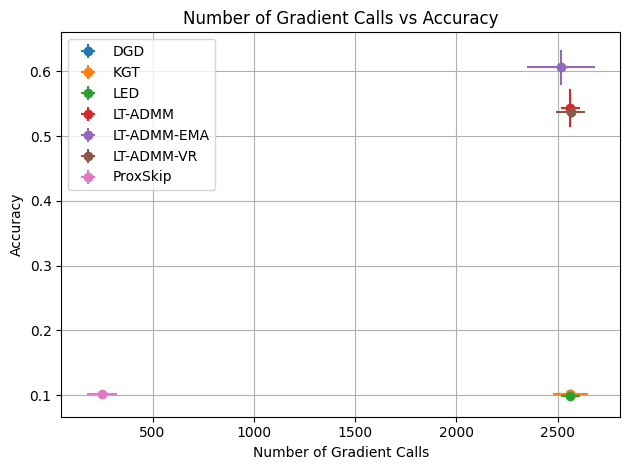

In [44]:
# Scatter plot of nr gradient calls vs accuracy with error bars when available
import matplotlib.pyplot as plt
for i, row in interested.iterrows():
    alg_name = row["algorithm"]
    accuracy = row["accuracy"]
    accuracy_std = row["accuracy_std"]
    nr_gradient_calls = row["nr sent messages"]
    nr_gradient_calls_std = row["nr sent messages_std"]
    plt.errorbar(
        nr_gradient_calls,
        accuracy,
        xerr=nr_gradient_calls_std,
        yerr=accuracy_std,
        fmt="o",
        label=alg_name,
    )
plt.xlabel("Number of Gradient Calls")
plt.ylabel("Accuracy")
plt.title("Number of Gradient Calls vs Accuracy")
plt.legend()
plt.tight_layout()
# plt.xscale("log")
plt.grid()
plt.show()

In [28]:
# Update metrics object to be the same and filter out algorithms
from copy import deepcopy

new_plot_data = deepcopy(plot_data)
new_plot_values = {}
new_table_values = {}
new_agent_metrics = {}
for alg, values in new_plot_data.plot_results.items():
    if "TORCH" in alg.name:
        display(f"Skipping {alg.name} since it is a TORCH algorithm")
        continue

    name_split = alg.name.split(" ")
    if len(name_split) > 1:
        match_name = name_split[0] + " "
    else:
        match_name = alg.name
    alg_res = result[result["algorithm"].str.match(match_name)]
    if len(alg_res) == 0:
        display(f"Could not find results for algorithm {alg.name} in dataframe, skipping")
        continue

    best_alg_name = alg_res.iloc[0]["algorithm"]
    if best_alg_name != alg.name:
        display(f"Algorithm name {alg.name} does not match best algorithm name {best_alg_name}, skipping")
        continue

    agent_metrics = new_plot_data.agent_metrics[alg] if new_plot_data.agent_metrics is not None else None
    # if "ss" in alg.name:
    #     # Remove ", ss: XXX" from name
    #     display(f"Original algorithm name: {alg.name}")
    #     alg.name = alg.name.split(", ss")[0]
    #     alg.name += ")"
    #     display(f"Updated algorithm name: {alg.name}")
    if "(" in alg.name:
        # Remove everything after "(" in name
        display(f"Original algorithm name: {alg.name}")
        alg.name = alg.name.split(" (")[0]
        display(f"Updated algorithm name: {alg.name}")

    new_plot_values[alg] = {}
    for metric, data in values.items():
        plot_metric_obj = [m for m in new_plot_data.plot_metrics if m.plot_description == metric.plot_description][0]
        new_plot_values[alg][plot_metric_obj] = data

    if new_plot_data.agent_metrics is not None:
        new_agent_metrics[alg] = agent_metrics

new_plot_data.plot_results = new_plot_values
new_plot_data.table_results = new_table_values
new_plot_data.agent_metrics = new_agent_metrics
plot_order = ["DGD", "KGT", "ProxSkip", "LED", "LT-ADMM", "LT-ADMM-VR", "LT-ADMM-EMA"]
new_plot_data.plot_results = dict(sorted(new_plot_data.plot_results.items(), key=lambda x: plot_order.index(x[0].name)))

'Original algorithm name: ProxSkip (p=0.10)'

'Updated algorithm name: ProxSkip'

'Algorithm name ProxSkip (p=0.20) does not match best algorithm name ProxSkip (p=0.10), skipping'

'Algorithm name LT-ADMM (ls=10) does not match best algorithm name LT-ADMM (ls=5), skipping'

'Original algorithm name: LT-ADMM (ls=5)'

...

'Original algorithm name: LED (ls=5)'

'Updated algorithm name: LED'

'Original algorithm name: KGT (ls=10)'

'Updated algorithm name: KGT'

'Algorithm name KGT (ls=5) does not match best algorithm name KGT (ls=10), skipping'

[04/09/26 20:10:49] WARNING  No table metrics to display.                                             ]8;id=406109;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=620192;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#55\55]8;;\

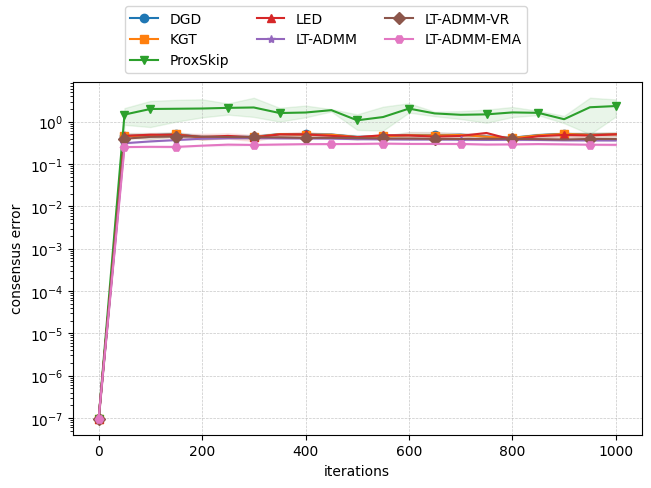

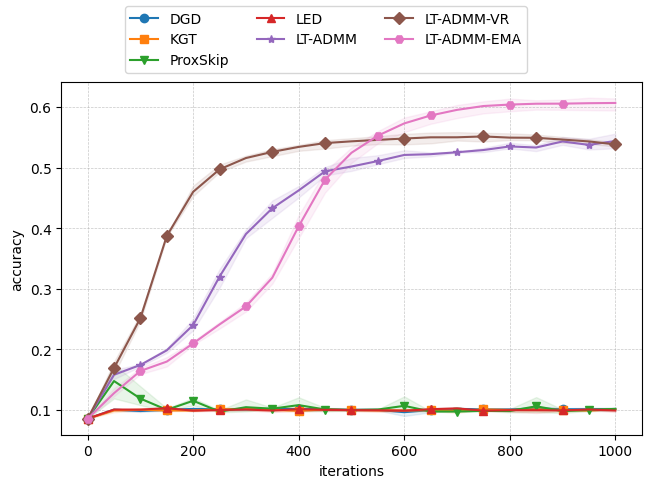

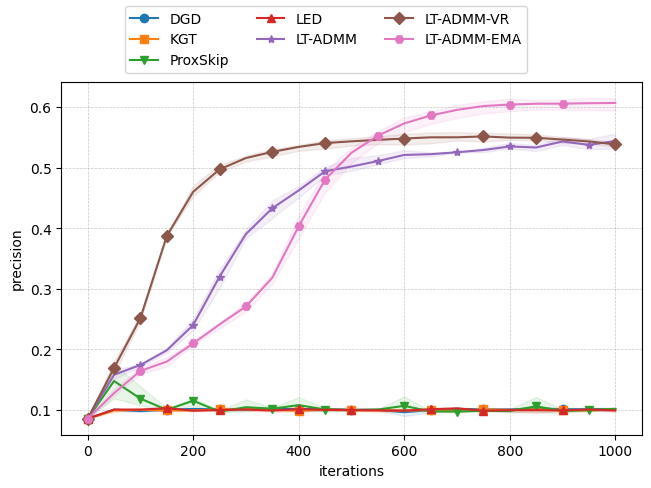

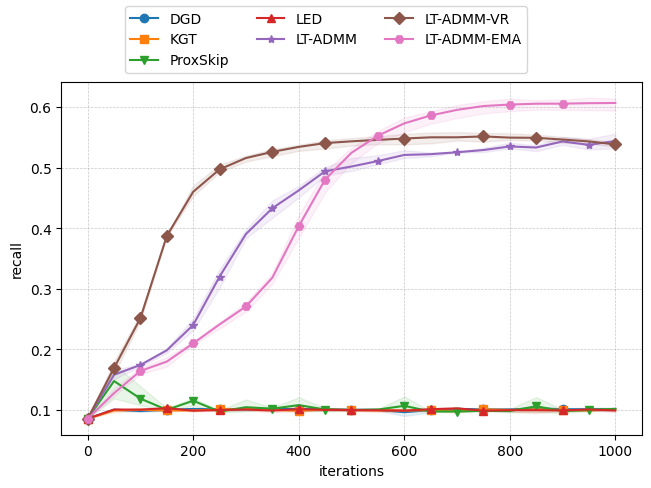

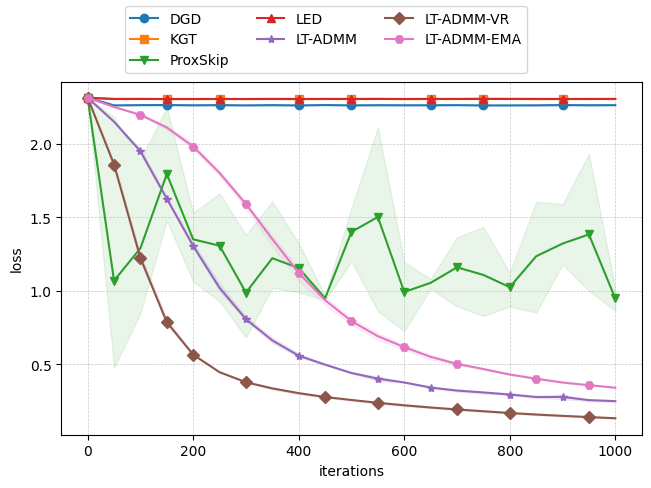

In [29]:
display_metrics(new_plot_data, individual_plots=True)